## Criteria for Resonance Capture and Stability

In [190]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle as pkl
import astropy.units as u
from pathlib import Path
import rebound_sims as reb_sims

def plot_prettier(dpi=200, fontsize=8, usetex=False): 
    '''
    Make plots look nicer compared to Matplotlib defaults
    Parameters: 
        dpi - int, "dots per inch" - controls resolution of PNG images that are produced
                by Matplotlib
        fontsize - int, font size to use overall
        usetex - bool, whether to use LaTeX to render fonds of axes labels 
                use False if you don't have LaTeX installed on your system
    '''
    plt.rcParams['figure.dpi']= dpi
    plt.rc("savefig", dpi=dpi)
    plt.rc('font', size=fontsize)
    plt.rc('xtick', direction='in') 
    plt.rc('ytick', direction='in')
    plt.rc('xtick.major', pad=5) 
    plt.rc('xtick.minor', pad=5)
    plt.rc('ytick.major', pad=5) 
    plt.rc('ytick.minor', pad=5)
    plt.rc('lines', dotted_pattern = [2., 2.])
    if usetex:
        plt.rc('text', usetex=usetex)
    else:
        plt.rcParams['mathtext.fontset'] = 'cm'
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

plot_prettier()

# === UNIT CONVERSIONS ===
AU = u.AU.to(u.cm)    
G = 4*np.pi**2 # in yr, AU, Msun
Msun = u.Msun.to(u.g) 
yr = u.yr.to(u.s)    
r_earth = u.earthRad.to(u.AU)
m_earth = u.Mearth.to(u.Msun)
r_sun = u.Rsun.to(u.AU) 

### <u>Adiabaticity criterion</u>

#### From Lin et al. (2025)

"Relatively slow migration is a necessary resonant capture condition. When the planets undergo fast convergent migration, they directly bypass the resonance before the eccentricities reach their equilibrium values."

For $j$:$j-1$ resonance, the resonance trapping criterion of slow migration for $q \ll 1$ is 
$$\tau_m > \frac{1}{n_1 ( 3(k-1))^{1/3}} \frac{1}{(\mu_2 \alpha f)^{4/3}}$$
where $\mu_i=m_i/M$ and $q=m_1/m_2$. Small $e$'s are assumed.

#### From Batygin & Morbidelli (2026)

In the limit of compact orbits, for $k$:$k-1$ resonance,
$$\frac{1}{\tau_a \Omega_1} \lesssim \frac{5\pi}{8}\left(\frac{5}{36k^5(k-1)^{2/3}}\right)^{1/3} \left(\frac{M}{m_1+m_2}\right)^{4/3}$$

which can be rewritten as

$$\tau_a \Omega_1 \gtrsim \left[ \frac{5\pi}{8}\left(\frac{5}{36k^5(k-1)^{2/3}}\right)^{1/3} \left(\frac{M}{m_1+m_2}\right)^{4/3} \right]^{-1}$$

#### From Batygin (2015)
Additionally, consider Eq. 43 in: [Batygin (2015)](https://arxiv.org/pdf/1505.01778)

### <u>Dissipative stability criterion</u>

#### From Batygin & Morbidelli (2026)

"In resonance, convergence migration excites $e$ while disk tides damp it, and long-lived trapping requires the existence of a fixed point in which these effects balance. As such, the resonant forcing must be sufficiently strong to offset $e$ damping... if $e$ damping is too strong relative to the resonant forcing, no stationary resonant equilibrium exists."

$$\frac{1}{\tau_a \Omega} \lesssim \frac{m_2}{M} \sqrt{\frac{32k^3 (1+\zeta) (\zeta \, \mathcal{K_1} + \mathcal{K_2})}{25\mathcal{K_1}\mathcal{K_2}}}$$
where $\mathcal{K_j} = \tau_a/\tau_{e_j}$. In simulations, $\mathcal{K_1}$ ranged from $10^{0.4}$ to $10^{3.4}$ while they set $\mathcal{K_2} = \mathcal{K_1}/\zeta$.

### <u>Eccentricity criterion</u>

#### From Batygin & Morbidelli (2026)

Orbits must possess sufficiently low eccentricities, which is guaranteed due to $e$ damping in a protoplanetary disk.

### <u>Overstability criterion</u>

#### From Deck & Batygin (2015)
For $m+1\text{:}m$ resonance, the condition for instability is (Eq. 15):
$$\epsilon_p < \epsilon_{p, \rm crit} \equiv \frac{3pm}{\mathcal{B}2^{3/2}} \frac{\tau_e}{\tau_{a,e}} \frac{(1+\zeta)^2}{\left(m(\zeta+1) + p\frac{\tau_e}{\tau_{a,e}}\right)^{3/2}} \left(\frac{\tau_e}{\tau_a}\right)^{3/2}$$

where 
$$\epsilon_p = \frac{m_1+m_2}{M}, \quad \zeta = \frac{m_1}{m_2}, \quad \mathcal{B} \approx 0.8m$$
$$R\equiv \frac{|f|}{g-\delta_{m,2}\alpha_{\rm res}}, \quad \alpha_{\rm res} = \frac{a_1}{a_2} = \left(\frac{k-1}{k}\right)^{2/3}$$
$$\tau_a = \left(\frac{1}{\tau_{a_2}} - \frac{1}{\tau_{a_1}} \right)^{-1}, \quad \tau_e = \left(\frac{1}{\tau_{e_1}} + \frac{\zeta}{\tau_{e_2}} \right)^{-1}, \quad \tau_{a,e} = \left(\frac{1}{\tau_{e_1}} - \frac{\zeta^2 \alpha_{\rm res}}{R^2 \tau_{e_2}} \right)^{-1}$$

See Eq. 15 in [Deck & Batygin (2015)](https://arxiv.org/pdf/1506.01382). Additionally, consider the escape criterion in Eq. 21.

#### From Batygin & Morbidelli (2026)

For low values of $\mathcal{K}$, resonance locking gives way to the onset of overstability of resonant librations. The instability criterion is

$$\left[ \frac{\zeta (k(1+\zeta)-2\zeta)}{1-\zeta} \frac{\chi_a}{\chi_e}\right]^{3/2} < \frac{15}{32} \frac{1-\zeta^2}{M/m_2}\left(\frac{h}{r}\right)^3$$
where $h/r$ is the aspect ratio, $\chi_a = 1/(2.7+1.1s)$, $\chi_e = 1/0.780$. However, there may be a typo here where it should be $m_2/M$ instead of $M/m_2$.

### <u>Damping timescales</u>

#### From Batygin & Morbidelli (2026)
$$\tau_{a_j} = \chi_a \left( \frac{m_j}{M} \frac{\Sigma a_j^2}{M} \left(\frac{h}{r}\right)^{-2} \Omega_j \right)^{-1}$$
$$\tau_{e_j} = \frac{\chi_e}{\chi_a} \left(\frac{h}{r}\right)^{2} \tau_{a_j}$$
where $h/r$ is the aspect ratio, $\chi_a = 1/(2.7+1.1s)$, $\chi_e = 1/0.780$.

### <u>K-Factors</u>
From Batygin & Morbidelli (2026), we have
$\mathcal{K_1} = \tau_a/\tau_{e_1}$ and $\mathcal{K_2} = \tau_a/\tau_{e_2}$. 

### Plotting the above criteria

In [4]:
m1 = 1e-3 * m_earth
m2 = 5 * m_earth
M = 1
s = 1
x_min, x_max = 3.87, 6.78
y_min, y_max = 1.8, 14

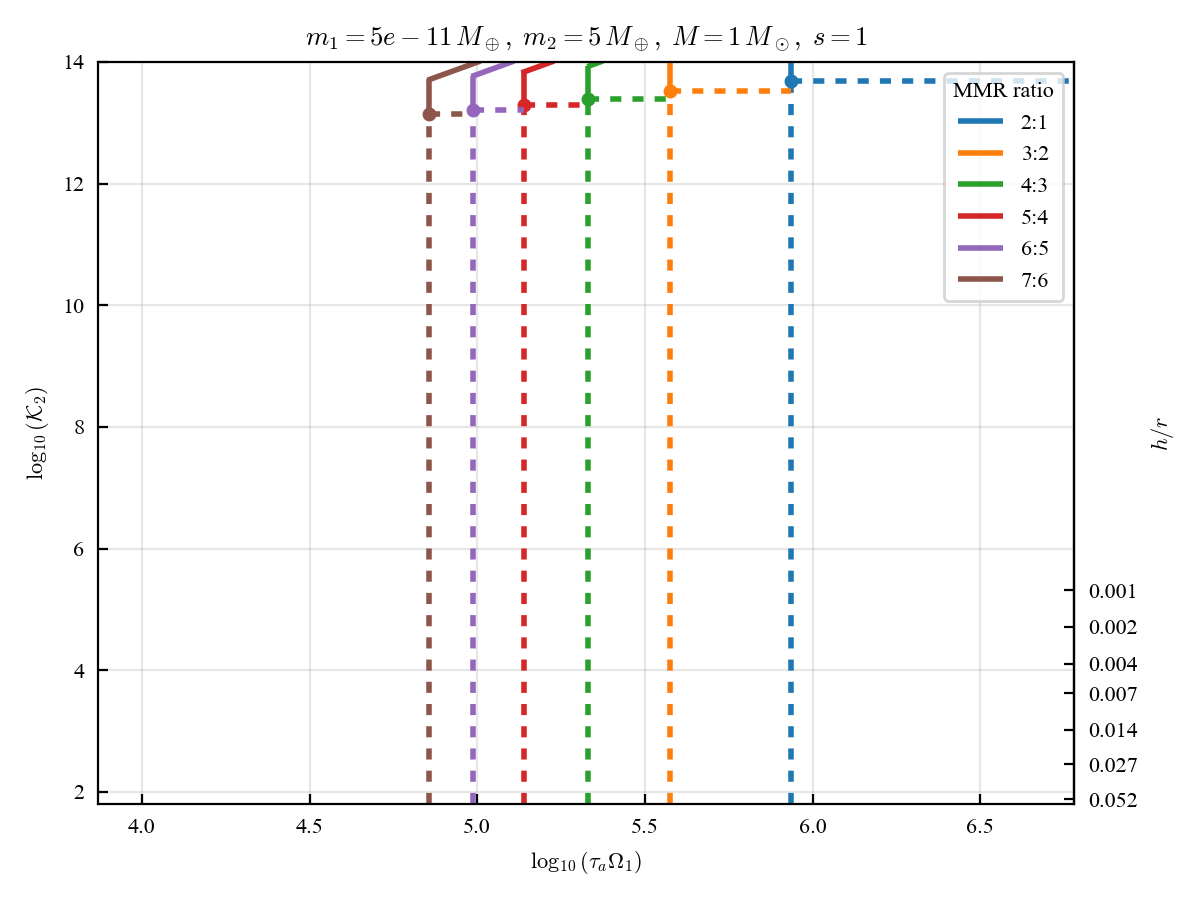

In [189]:
zeta = m1 / m2
chi_a = 1 / (2.7 + 1.1 * s)
chi_e = 1 / 0.780

def adiabaticity_crit(k):
    """
    Returns C_k for:
        1 / (tau_a * Omega_1) <= C_k
    """
    
    # # Batygin 2015
    # if k == 2:
    #     # first-order resonance coefficient
    #     with open("fg_library.pkl", "rb") as f:
    #         fg_lib = pkl.load(f)

    #     f, g = fg_lib[(2, 1)]
    #     f_res = f

    #     P = 0.25**(3/2)
    #     Omega = 2*np.pi / P
    #     Mstar = 1
    #     C = (
    #         np.pi**2
    #         * Omega**3
    #         * (Mstar/(m1+m2))**(4/3)
    #         * (k-1)**(-2/9)
    #         * np.sqrt(3)
    #         * abs(f_res)**(4/3)
    #     )

    #     return C
    
    # "Compact case" from B&M 2026
    if k > 1:
        return (
            (5 * np.pi / 8)
            * (5 / (36 * k**5 * (k - 1)**(2/3)))**(1/3)
            * (M / (m1 + m2))**(4/3)
        )

def dissipative_crit(k, K1, K2):
    """
    Returns C_k for:

        1 / (tau_a * Omega_1) <= C_k
    """
    return (
        (m2 / M)
        * np.sqrt(
            32 * k**3 * (1 + zeta) * (zeta * K1 + K2)
            / (25 * K1 * K2)
        )
    )

def overstability_K2_crit(k):
    lhs_base = (
        zeta
        * (k * (1 + zeta) - 2 * zeta)
        / (1 - zeta)
        * (chi_a / chi_e)
    )

    A = lhs_base**(3/2)
    B = (15 / 32) * (1 - zeta**2) / m2 # fixed typo

    h_crit = (A / B)**(1/3) # critical aspect ratio
    K2_crit = chi_a/chi_e / (1-zeta) * h_crit**-2 
    
    return K2_crit

logK2 = np.linspace(y_min, y_max, 600)
K2 = 10**logK2
K1 = K2 * zeta

fig, ax = plt.subplots(figsize=(6, 4.5))

x_adia_prev = x_max
for k in range(2, 8):
    color = f"C{k-2}"

    C_adia = adiabaticity_crit(k)
    C_diss = dissipative_crit(k, K1, K2)

    x_adia = np.log10(C_adia)
    x_diss = -np.log10(C_diss)

    transition_idx = np.argmax(x_diss >= x_adia)

    if x_diss[transition_idx] < x_adia:
        y_transition = y_max
    else:
        y_transition = logK2[transition_idx]

    K2_over = overstability_K2_crit(k)
    y_over = np.log10(K2_over)

    y_adia_start = max(y_min, y_over)

    if y_adia_start < y_transition:
        ax.vlines(
            x=x_adia,
            ymin=y_adia_start,
            ymax=min(y_transition, y_max),
            lw=2,
            color=color,
            label=rf"{k}:{k-1}"
        )
        ax.vlines(
            x=x_adia,
            ymin=y_min,
            ymax=y_adia_start,
            lw=2,
            color=color,
            ls=":"
        )
    
    mask = logK2 >= max(y_transition, y_over)

    ax.plot(
        x_diss[mask],
        logK2[mask],
        lw=2,
        color=color,
    )

    if y_min <= y_over <= y_max:
        ax.hlines(
            y=y_over,
            xmin=x_adia,
            xmax=x_adia_prev,
            lw=2,
            color=color,
            ls=":",
        )
    
        x_adia_prev = x_adia
    
        ax.plot(x_adia, y_over, "o", color=color, ms=4)

# log K2 axis

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.set_xlabel(r"$\log_{10}(\tau_a\Omega_1)$")
ax.set_ylabel(r"$\log_{10}(\mathcal{K}_2)$")

# h/r axis

A = (chi_a / chi_e) / (1 - zeta)

def logK2_to_hr(logK2):
    K2 = 10**logK2
    return np.sqrt(A / K2)

def hr_to_logK2(hr):
    K2 = A / hr**2
    return np.log10(K2)

ax2 = ax.secondary_yaxis(
    'right',       
    functions=(logK2_to_hr, hr_to_logK2)
)
ax2.set_ylabel(r"$h/r$")
ax2.set_yticks(np.round(np.logspace(-3, -1, 8), 3))

ax.legend(title="MMR ratio")
ax.set_title(
    rf"$m_1={m1/m_earth:.4g}\,M_\oplus,\;"
    rf"m_2={m2/m_earth:.4g}\,M_\oplus,\;"
    rf"M={M:.4g}\,M_\odot,\;"
    rf"s={s:.3g}$"
)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

%matplotlib widget

### Overstability Using Deck & Batygin (2015)

Set up a fake simulation.

In [165]:
# Obtain timescales

def fake_sim(k, Sigma_1au, h_1au, a1=1, m_em=0.1):
    # k:k-1 MMR
    # === PARAMETERS ===
    planets = {
        "name": ['planet b', 'planet c', 'planet d'],
        "m_vals": [4, 5, 5], # [m_earth]
        "a_vals": [a1, a1/((k-1)/k)**(2/3), 2], # [AU]
        "r_vals": [10, 10, 10] # [r_earth]; twice the current values
    }

    num_pl = 3
    num_em = 1
    num_ptsml = 1

    rock_names = planets['name'][:num_pl] + [f"embryo {i}" for i in range(num_em)] + [f"ptsml {i}" for i in range(num_ptsml)]
        
    # Setting up em/ptsml disk
    r_em = (m_em)**(1/3) # [r_earth]
    m_ptsml = 0.00033 # [m_earth]
    r_ptsml = (100*1e5/AU)/r_earth # 100 km in [r_earth]
    small_body_a_vals = np.linspace(a1, 0.9, num_em+num_ptsml) # equally spaced locations in disk range
    em_indices = np.round(np.linspace(0, len(small_body_a_vals) - 1, num=num_em)).astype(int) # picks num_em equally spaced indices
    em_a_vals = small_body_a_vals[em_indices]
    ptsml_a_vals = np.delete(small_body_a_vals, em_indices)
        
    # Combine values for planets, ems, ptsmls
    m_vals = np.array(planets['m_vals'][:num_pl] + [m_em]*num_em + [m_ptsml]*num_ptsml) * m_earth
    r_vals = np.array(planets['r_vals'][:num_pl] + [r_em]*(num_em) + [r_ptsml]*num_ptsml) * r_earth
    m_star = 1. # Msun
    r_star = 1.5 * r_sun
    a_vals = np.concatenate((planets['a_vals'][:num_pl], em_a_vals, ptsml_a_vals)) # Initial a_vals
        
    # Full parameter space
    alpha = 1
    beta = 0                                  # Converted to Msun/AU^2 from g/cm^2
    tau_a = 1/(2.7+1.1*alpha) / m_vals[0] / (Sigma_1au*AU**2 / Msun) * h_1au**2 / (2*np.pi) # for a = 1

    parameters = {"m_vals": m_vals,
                "m_star": m_star,
                "r_vals": r_vals,
                "r_star": r_star,
                "a_vals": a_vals,
                "num_pl": num_pl,
                "num_em": num_em,
                "num_ptsml": num_ptsml,
                "ide_position": 0.1,
                "ide_width": h_1au * 0.1**beta,
                "Sigma_1au": Sigma_1au, # should be given in g/cm^2
                "h_1au": h_1au,
                "alpha": alpha,
                "beta": beta,
                "m_em": m_em,
                "r_em": r_em,
                "m_ptsml": m_ptsml,
                "r_ptsml": r_ptsml,
                } 

    import rebound
    # Create the simulation
    sim = rebound.Simulation()
    sim.units = ('AU', 'yr', 'Msun')
    sim.add(m=parameters["m_star"], r=parameters["r_star"], hash='star')

    for i in range(len(rock_names)):
        sim.add(
            m=parameters['m_vals'][i], 
            r=parameters['r_vals'][i], 
            a=parameters['a_vals'][i], 
        )

    ps = sim.particles
    
    return ps, parameters

In [187]:
from timescales import tau_t1_mig, tau_gas

k = 5
Sigma_1au = 1700
h_1au = 0.08
a1 = 0.5
m_em = 5e-11*m_earth

ps, parameters = fake_sim(k, Sigma_1au, h_1au, a1, m_em)
m_vals = parameters['m_vals']
m1, m2 = m_em, m_vals[1] # solar masses
zeta = m1/m2
m_star = 1 # solar masses

# ta_p1, te_p1 = -np.array(tau_t1_mig(ps[1], parameters))[0:2] # planet b
ta_p2, te_p2 = -np.array(tau_t1_mig(ps[2], parameters))[0:2] # planet c

ta_p1_mig, te_p1_mig = -np.array(tau_t1_mig(ps[4], parameters))[0:2] # em t1mig
ta_p1_gas, te_p1_gas = -np.array(tau_gas(ps[4], parameters))[0:2] # em gas
ta_p1 = 1/(1/ta_p1_gas + 1/ta_p1_mig)
te_p1 = 1/(1/te_p1_gas + 1/te_p1_mig)

ta = 1/(1/ta_p2 - 1/ta_p1)
Omega1 = 2*np.pi / ps[1].P

print(f"{k}:{k-1} MMR")
print(f"Sigma_1au: {Sigma_1au}, h_1au: {h_1au}")
print(f"a1: {a1}, a2: {parameters['a_vals'][1]:.3g}")
print(f'm1: {m1/m_earth:.2g} m_earth, m2: {m2/m_earth:.2g} m_earth')
print(f"zeta: {zeta:.2g}")
print(f't_a1: {ta_p1:.0f}, t_e2: {te_p1:.0f}')
print(f't_a2: {ta_p2:.0f}, t_e2: {te_p2:.0f}')
print(f'log_t_a_Omega: {np.log10(ta*Omega1):.2f}')
print(f'log_K2: {np.log10(ta/te_p2):.2f}')

5:4 MMR
Sigma_1au: 1700, h_1au: 0.08
a1: 0.5, a2: 0.58
m1: 5e-11 m_earth, m2: 5 m_earth
zeta: 1e-11
t_a1: 6843, t_e2: 60
t_a2: 71058, t_e2: 2216
log_t_a_Omega: nan
log_K2: nan


In [188]:
def get_crit_ep(k, p):
    # Batygin: k:k-1, so 7:6 MMR has k=7
    # Deck: m+1:m, so 7:6 MMR has m=6
    # p is the coupling parameter
    m = k-1
    print(f"{k}:{k-1} MMR")

    B = 0.8*m

    zeta = m1/m2
    print(f"zeta: {zeta:.5f}")
    
    alphares = ((k-1)/k)**(2/3) # a1/a2
    print(f"α_res: {alphares:.3f}")
    with open("fg_library.pkl", "rb") as f:
        fg_lib = pkl.load(f)

    f, g = fg_lib[(k, 1)] # 1st order

    if k != 2: # or if m != 1
        R = abs(f)/g # if not 2:1
    else:
        R = abs(f)/(g - 2*alphares)

    ta1, te1 = ta_p1, te_p1 # inner
    ta2, te2 = ta_p2, te_p2  # ouer

    ta = (1/ta2 - 1/ta1)**-1
    te = (1/te1 + zeta/te2)**-1
    tae = (1/te1 - zeta**2 * alphares / (R**2 * te2))**-1 

    ep_p = (m1+m2)/m_star
    C = (3*p*m)/(B * 2**1.5) * te/tae * (1+zeta)**2 / (m*(zeta+1) + p*te/tae)**1.5
    ep_p_crit = C * (te/ta)**1.5
    
    print(f"ε_p: {ep_p:.4g}") # Overstable if over ep_p_crit
    print(f"ε_p,crit: {ep_p_crit:.4g}") 
    
    if ep_p < ep_p_crit:
        print("ep_p < ep_p_crit (overstable)")
    elif ep_p >= ep_p_crit:
        print("ep_p ≥ ep_p_crit (stable)")
        
get_crit_ep(k, p=2)

5:4 MMR
zeta: 0.00000
α_res: 0.862
ε_p: 1.502e-05
ε_p,crit: nan


### Plotting $\delta$ vs $e_r$

Leleu et al. (2026) gives

$$\delta = \frac{2}{3} \left(\frac{C_\delta f_{\rm super}}{M^{2/3}}+R\right) - 1$$

$$C_\delta = \left(\frac{3p^{1/2}}{|f_1|}\right)^{2/3}$$

Replacing $R$ by $e_r^2/2$, we obtain $$\Delta_R = \frac{1}{2} (3(\delta + 1) - e_r^2) C_\delta^{2/3} M^{2/3}$$

Additionally, 

$$\Delta_{\rm MMR} = e_r^2 - 3(\delta + 1) = K_p M^{-2/3} \left[\left( \frac{P_2}{P_1}\frac{p}{p+1}\right)^{1/3}-1\right]$$

$$f_{\rm super} = 2\pi \left(\frac{p}{P_1} - \frac{p+1}{P_2} \right)$$

$$M \approx M_C = \left(\frac{m_1 + \left(\frac{p}{p+1}\right)^{2/3} m_2}{m_\star}\right)$$
for $p+1$:$p$ MMR.

In [ ]:
def compute_R(a1,a2,e1,e2,pomega1,pomega2,m1,m2,m_star,f1,f2,G=1):
    Lambda1 = m1*np.sqrt(G*m_star*a1)
    Lambda2 = m2*np.sqrt(G*m_star*a2)

    # check normalization against Leleu appendix
    Kr = Lambda1*Lambda2/(Lambda1+Lambda2)

    R = Kr * (
        f1**2*e1**2
        + f2**2*e2**2
        + 2*f1*f2*e1*e2*np.cos(pomega1-pomega2)
    )

    return R

def compute_delta_er(P1,P2,a1,a2,e1,e2,pomega1,pomega2,m1,m2,m_star,p,f1,f2,G=1):

    # super-frequency
    fsuper = 2*np.pi*(p/P1-(p+1)/P2)

    # mass parameter
    M = (m1+(p/(p+1))**(2/3)*m2)/m_star

    # resonant coefficient
    Cdelta = (3*np.sqrt(p)/abs(f1))**(2/3)

    R = compute_R(a1,a2,e1,e2,pomega1,pomega2,m1,m2,m_star,f1,f2,G)
    Rmax = R.max()
    
    er = np.sqrt(2*Rmax)    
    delta = 2/3*(Cdelta*fsuper/M**(2/3)+R) - 1

    return delta, er

with open("fg_library.pkl", "rb") as f:
    fg_lib = pkl.load(f)

p = 3 # for p+1:p resonance
# From Table B1
f1 = [1.1904936978, 2.0252226899, 2.8404318567, 3.6496182441, 4.4561427851][p-1]
f2 = -[0.4283898341, 2.4840051833, 3.2832567218, 4.0837053718, 4.8847062975][p-1]

dataset_id = 7
sim_id = 155
base_dir = Path.cwd()
file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"
saved_sim = reb_sims.load_simulation_run(file_path)

sim_data, metadata = saved_sim

m1, m2, m_star = metadata['m_vals'][0], metadata['m_vals'][1], metadata['m_star']
P1, P2 = sim_data['planet b']['P'].iloc[-1], sim_data['planet c']['P'].iloc[-1]
a1, a2 = sim_data['planet b']['a'].iloc[-1], sim_data['planet c']['a'].iloc[-1]
e1, e2 = sim_data['planet b']['e'].iloc[-1], sim_data['planet c']['e'].iloc[-1]
pomega1, pomega2 = sim_data['planet b']['pomega'].iloc[-1], sim_data['planet c']['pomega'].iloc[-1]

delta, er = compute_delta_er(P1,P2,a1,a2,e1,e2,pomega1,pomega2,m1,m2,m_star,p,f1,f2)
print(f"δ = {delta:.4g}, e_r = {er:.4g}")

In [ ]:
p = 3 # for p+1:p resonance
f1, f2 = fg_lib[(p+1, p)]
print(-f1, f2)